# Persamaan Parabolic

Sekarang kita akhirnya beralih untuk menggabungkan apa yang telah kita pelajari mengenai diskretisasi spasial pada masalah nilai batas dengan diskretisasi temporal pada masalah nilai awal. Jenis persamaan pertama yang akan kita pelajari adalah persamaan parabolik, di mana persamaan panas
$$
    u_t = \kappa u_{xx}
$$

akan menjadi fokus utama kita. Banyak sifat umum dari metode numerik yang akan kita turunkan untuk persamaan panas ini juga akan berlaku untuk banyak persamaan parabolik lainnya.

Bersama dengan persamaan di atas, kita juga memerlukan kondisi batas
$$\begin{aligned}
    u(0, t) &= g_0(t) \quad \text{for} \quad &t > 0 & \text{   and} \\
    u(1, t) &= g_1(t) \quad \text{for} \quad &t > 0 &
\end{aligned}$$
serta kondisi awal
$$
    u(x, 0) = u_0(x).
$$
Di sini kita mengasumsikan bahwa domain kita adalah $\Omega = [0, 1]$, $t_0 = 0$, dan bahwa kita memiliki kondisi batas Dirichlet (kita akan melihat implementasi lainnya nanti).

Kita juga akan mendiskretisasi domain ruang-waktu sedemikian sehingga
$$
    x_i = i \Delta x \quad \quad t_n = n \Delta t
$$
dan bahwa diskretisasi numerik kita $U$ akan mendekati fungsi sebenarnya $u$ pada suatu titik $(x_i, t_n)$ sehingga
$$
    U^n_i \approx u(x_i, t_n).
$$

Sebagai upaya pertama untuk mendiskretisasi persamaan panas, mari kita gunakan forward Euler untuk mendiskretisasi dalam waktu dan perbedaan terpusat orde ke-2 dalam ruang untuk mendapatkan
$$
    \frac{U^{n+1}_i - U^n_i}{\Delta t} = \frac{1}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$
atau dalam bentuk pembaruan
$$
    U^{n+1}_i = U^n_i + \frac{\Delta t}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1}).
$$

Salah satu cara untuk memandang diskretisasi ini adalah dengan mempertimbangkan kembali ini sebagai masalah nilai awal sehingga
$$
    U^{n+1}_i = U^n_i + \Delta t f(t_n, U^n_i)
$$
di mana diskretisasi spasial sekarang terkandung dalam $f$ sehingga dalam kasus di atas kami memiliki
$$
    f(t_n, U^n_i) = \frac{1}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$
memberikan kita sarana untuk menganalisis metode ini dalam konteks metode numerik masalah nilai awal.

Metode lain yang menggunakan hanya satu langkah tetapi lebih praktis seperti yang akan kita lihat disebut metode *Crank-Nicholson*. Metode ini didasarkan pada diskretisasi metode trapesium sehingga
$$\begin{aligned}
    \frac{U^{n+1}_i - U^n_i}{\Delta t} &= \frac{1}{2} (f(U^n_i) + f(U^{n+1}_i)) \\
    &= \frac{1}{2} \frac{U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1}}{\Delta x^2} \Rightarrow \\
    U^{n+1}_i &= U^n_i + \frac{\Delta t}{2 \Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1})
\end{aligned}$$

Coba menggambar stensil dari metode ini.

Dari rumus pembaruan kita dapat melakukan sedikit aljabar untuk mencari
$$
    -r U^{n+1}_{i-1} + (1 + 2r) U^{n+1}_i - r U^{n+1}_{i+1} = r U^{n}_{i-1} + (1 - 2r) U^{n}_{i} + r U^{n}_{i+1}
$$
di mana $r = \frac{\Delta t}{2 \Delta x^2}$.

Coba menuliskan sistem persamaan untuk ini jika kita memiliki $m=5$.

Ini membentuk sistem persamaan tridiagonal dengan bentuk $A U^{n+1} = f(t_n, U^n)$ di mana
$$
    A = \begin{bmatrix}
        1+2r & -r \\
        -r & 1+2r & -r \\
        & -r & 1+2r & -r \\
        & & \ddots & \ddots & \ddots \\
        & & & -r & 1+2r & -r \\
        & & & & -r & 1+2r
    \end{bmatrix}
$$
$$
    f(t_n, U^{n}) = \begin{bmatrix}
        r (g_0(t_n) + g_0(t_{n+1})) + (1 - 2r) U^n_1 + r U^n_2 \\
        r U^n_1 + (1-2r) U^n_2 + r U^n_3 \\
        r U^n_2 + (1-2r) U^n_3 + r U^n_4 \\
        \vdots \\
        r U^n_{m-2} + (1-2r) U^n_{m-1} + r U^n_m \\
        r U^n_{m-1} + (1-2r) U^n_m + r(g_1(t_n) + g_1(t_{n+1}))
    \end{bmatrix}
$$

Dari diskusi kita tentang metode iteratif kita mungkin dapat menyelesaikan ini dalam $\mathcal{O}(m)$ langkah membuat metode Crank-Nicholson untuk persamaan panas seefisien metode eksplisit kita di atas. Keuntungan dari metode implisit adalah bahwa hal itu memungkinkan langkah waktu yang jauh lebih besar daripada metode eksplisit karena batasan stabilitas yang akan kita lihat secara detail (persamaan panas dapat dianggap sebagai sistem ODE yang kaku).

## Kesalahan Truncasi Lokal

Kesalahan truncasi lokal $\tau^n$ dihitung kembali dengan cara yang sama seperti sebelumnya, kecuali sekarang kita perlu menangani baik turunan temporal maupun turunan spasial. Kita masih akan mengikuti prosedur yang sama seperti sebelumnya, memasukkan solusi sebenarnya $u(x,t)$ ke dalam diskretisasi yang sesuai dan menggunakan ekspansi Taylor untuk menemukan suku kesalahan yang dominan.

Sebagai contoh, pertimbangkan metode eksplisit yang dikembangkan di atas. Kita sekarang memiliki
$$
    \tau^n_i = \tau(x_i, t_n) = \frac{u(x, t + \Delta t) - u(x, t)}{\Delta t} - \frac{1}{\Delta x^2} (u(x - \Delta x, t) - 2 u(x, t) + u(x + \Delta x, t))
$$

Ekspansi Taylor yang relevan adalah
$$\begin{aligned}
    u(x, t + \Delta t) &= u(x,t) + u_t(x,t) \Delta t + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4) \\
    u(x \pm \Delta x, t) &= u(x,t) \pm \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) \pm \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5).
\end{aligned}$$

Ini menghasilkan kesalahan truncasi sebesar
$$\begin{aligned}
    \tau(x,t) &= \frac{1}{\Delta t} \left(u(x,t) + u_t(x,t) \Delta t + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4) - u(x,t) \right ) \\
    & \quad - \frac{1}{\Delta x^2} \left (u(x,t) - \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) - \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) \right .\\
    & \quad - 2 u(x,t) \\
    & \quad \left .+ u(x,t) + \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) + \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5)\right ) \\
    &= u_t(x,t)+ \frac{\Delta t}{2} u_{tt}(x,t) + \frac{\Delta t^2}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^3)  - u_{xx}(x,t) - \frac{\Delta x^2}{24} u_{xxxx}(x,t) - \frac{\Delta x^2}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5) \\
    &=  \frac{\Delta t}{2} u_{tt}(x,t) + \frac{\Delta t^2}{6} u_{ttt}(x,t) - \frac{\Delta x^2}{12} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^4, \Delta t^2)
\end{aligned}$$

Untuk menyederhanakan ekspresi kesalahan truncasi kita dapat membedakan solusi sebenarnya melalui
$$
    (u_t)_t = (u_{xx})_t \rightarrow u_{tt} = (u_t)_{xx} = u_{xxxx}
$$
mengasumsikan solusi cukup halus sehingga kita dapat menggantikan turunan temporal dalam kesalahan truncasi kita untuk menemukan
$$\begin{aligned}
    \tau(x,t) &= \left ( \frac{\Delta t}{2} - \frac{\Delta x^2}{12} \right) u_{xxxx} + \mathcal{O}(\Delta t^2, \Delta x^4)
\end{aligned}$$
yang membawa kita pada kesimpulan bahwa metode ini orde satu dalam waktu dan orde dua dalam ruang. Kita lihat bahwa metode eksplisit di atas paling tidak konsisten.

Kita juga dapat menunjukkan bahwa metode Crank-Nicholson orde dua dalam waktu dan orde dua dalam ruang, yaitu
$$
    \tau(x,t) = \mathcal{O}(\Delta t^2, \Delta x^2).
$$

## Metode Garis

Metode *metode garis* mengacu pada mendiskretisasi komponen spasial dan temporal dari PDE secara terpisah. Ini berguna untuk menganalisis metode serta sebagai cara langsung untuk memastikan kesalahan truncasi tertentu. Di atas kita telah menggunakan pendekatan ini pada persamaan panas dengan mendiskretisasi turunan spasial menggunakan pendekatan terpusat orde dua untuk turunan kedua yang menghasilkan sistem ODE, yang sering disebut *metode semi-diskret*.

Melihat kembali contoh kita, pendekatan metode garis akan memberi kita sistem
$$
    U_i'(t) = \frac{1}{\Delta x^2} (U_{i-1}(t) - 2 U_i(t) + U_{i+1}(t))
$$
yang dapat kita terapkan metode IVP apa pun (dan dengan demikian dua pendekatan berbeda di atas).

## Stabilitas

Dengan perspektif metode garis kita dapat melihat diskretisasi persamaan panas sebagai pertanyaan apakah $\Delta t \lambda = z$ berada di dalam daerah stabilitas dari metode ODE tertentu. Sekarang kita melihat bagaimana $\lambda$ dari diskretisasi spasial dapat memainkan peran penting dalam stabilitas pendekatan metode keseluruhan.

Untuk persamaan panas dengan pendekatan terpusat orde kedua kita tahu bahwa nilai eigen matriks adalah
$$
    \lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1).
$$
Seperti sebelumnya ketika $\Delta x \rightarrow 0$ nilai eigen terus menjadi lebih besar sepanjang sumbu real negatif tetapi nilai eigen terkecil tetap stasioner. Ini membuat kita menyimpulkan bahwa semakin kecil $\Delta x$ menjadi, BVP menjadi lebih *kaku* dan hal yang sama terjadi di sini. Faktanya, dalam kasus ini kita melihat bagaimana ini berdampak buruk pada pendekatan IVP kita.

For the heat equation the largest eigenvalue goes as
$$
    \lambda = -\frac{4}{\Delta x^2}
$$
so we require that 
$$
    z =  -\frac{4 \Delta t}{\Delta x^2}
$$
lie within the stability region of the IVP method we have chosen.

Untuk metode eksplisit di atas kita memerlukan
$$
    |1 + \Delta t \lambda| \leq 1
$$
dan oleh karena itu
$$
    \frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}
$$

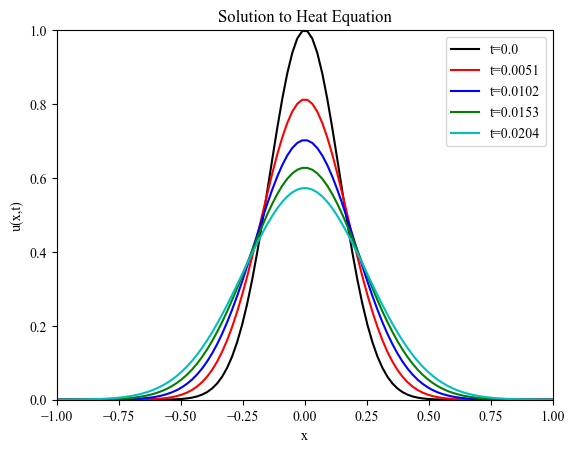

In [3]:
import numpy as np          # Untuk operasi numerik dan array
import matplotlib.pyplot as plt  # Untuk membuat grafik/plot
import matplotlib as mpl

# Set font Times New Roman untuk seluruh grafik
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

# DISKRITISASI RUANG (Spatial Discretization)
m = 100  # Jumlah titik grid pada sumbu x

# Membuat array x dari -1.0 hingga 1.0 sebanyak m titik
x = np.linspace(-1.0, 1.0, m)

# Menghitung jarak antar titik grid (Δx)
delta_x = 2.0 / (m - 1.0)

# DISKRITISASI WAKTU (Time Discretization)

# Menghitung langkah waktu (Δt) berdasarkan syarat stabilitas CFL:
# Δt ≤ 0.5 * Δx² agar solusi Forward Euler stabil
delta_t = 0.5 * delta_x**2

N = 101  # Jumlah langkah waktu

# Membuat array waktu dari 0 hingga N*Δt dengan interval Δt
t = np.arange(0.0, N * delta_t, delta_t)

# ARRAY SOLUSI

# Membuat array kosong U berukuran (N+1) x m
# Baris = indeks waktu, Kolom = indeks posisi x
U = np.empty((N + 1, m))

# KONDISI AWAL & BATAS (Initial & Boundary Conditions)

# Kondisi awal t=0: fungsi Gaussian terpusat di x=0
# U(x, 0) = exp(-x² / 0.2²)
U[0, :] = np.exp(-x**2 / 0.2**2)

# Kondisi batas Dirichlet: nilai u = 0 di kedua ujung domain
g_0 = lambda t: 0.0  # Batas kiri  x = -1
g_1 = lambda t: 0.0  # Batas kanan x =  1

# LOOP TIME STEPPING (Forward Euler)

for n in range(len(t)):  # Iterasi setiap langkah waktu

    # Update titik-titik interior menggunakan skema beda hingga orde-2
    # U[n+1,i] = U[n,i] + (Δt/Δx²) * (U[n,i-1] - 2*U[n,i] + U[n,i+1])
    for i in range(1, len(x) - 1):
        U[n+1, i] = U[n, i] + delta_t / delta_x**2 * (
            U[n, i-1] - 2.0 * U[n, i] + U[n, i+1]
        )

    # Update titik batas kiri (x = -1) menggunakan nilai g_0
    U[n+1, 0] = U[n, 0] + delta_t / delta_x**2 * (
        g_0(t[n]) - 2.0 * U[n, 0] + U[n, 1]
    )

    # Update titik batas kanan (x = 1) menggunakan nilai g_1
    U[n+1, -1] = U[n, -1] + delta_t / delta_x**2 * (
        U[n, -2] - 2.0 * U[n, -1] + g_1(t[n])
    )

# VISUALISASI SOLUSI

# Daftar warna untuk setiap kurva yang diplot
colors = ['k', 'r', 'b', 'g', 'c']

# Membuat figure dan axes untuk plot
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot solusi pada 5 titik waktu: n = 0, 25, 50, 75, 100
for (i, n) in enumerate((0, 25, 50, 75, 100)):
    axes.plot(
        x, U[n, :],         # Plot u(x) pada waktu ke-n
        colors[i],           # Warna kurva
        label='t=%s' % np.round(t[n], 4)  # Label menampilkan nilai waktu
    )

# Pengaturan label dan judul grafik
axes.set_xlabel("x")                        # Label sumbu x
axes.set_ylabel("u(x,t)")                   # Label sumbu y
axes.set_title("Solution to Heat Equation") # Judul grafik
axes.set_xlim([-1, 1])                      # Batas sumbu x
axes.set_ylim([0.0, 1.0])                   # Batas sumbu y

# Menampilkan legenda dan grafik
axes.legend()
plt.show()

Untuk Metode Crank-Nicholson kita tahu bahwa metode trapesium stabil absolut sehingga kita dapat memilih $\Delta t$ apa pun. Jika $\Delta t$ terlalu besar kita mungkin kehilangan akurasi meskipun demikian sehingga kita perlu sedikit hati-hati saat menggunakan metode ini. Secara umum kita dapat memilih $\Delta t = \mathcal{O}(\Delta x)$ untuk mendapatkan solusi yang wajar.

In [ ]:
import numpy as np                        # Library untuk operasi numerik dan array
import matplotlib as mpl                  # Library untuk pengaturan global grafik
import scipy.sparse as sparse             # Library untuk matriks sparse (jarang/efisien)
import scipy.sparse.linalg as linalg      # Library untuk solver sistem persamaan sparse

%matplotlib inline

mpl.rcParams['font.family'] = 'serif'            # Mengatur jenis keluarga font menjadi serif
mpl.rcParams['font.serif'] = ['Times New Roman'] # Mengatur font spesifik menjadi Times New Roman

# DISKRITISASI RUANG (Spatial Discretization)
m = 100                                   # Jumlah titik grid pada sumbu x
x = np.linspace(-1.0, 1.0, m)            # Membuat array x dari -1 hingga 1 sebanyak m titik
delta_x = 2.0 / (m - 1.0)               # Menghitung jarak antar titik grid (Δx)
print("delta_x = %s" % delta_x)          # Menampilkan nilai Δx ke layar

# DISKRITISASI WAKTU (Time Discretization)
C = 0.5                                   # Konstanta Courant untuk mengontrol akurasi waktu
delta_t = C * delta_x                     # Menghitung langkah waktu (Δt) berdasarkan konstanta Courant
t = np.arange(0.0, 1.0, delta_t)         # Membuat array waktu dari 0 hingga 1 dengan interval Δt
N = len(t)                                # Menghitung jumlah total langkah waktu
print("delta_t = %s" % delta_t)          # Menampilkan nilai Δt ke layar

# ARRAY SOLUSI
U = np.empty((N + 1, m))                 # Membuat array kosong U berukuran (N+1) x m
                                          # Baris = indeks waktu, Kolom = indeks posisi x

# KONDISI AWAL & BATAS
U[0, :] = np.exp(-x**2 / 0.2**2)        # Kondisi awal t=0: fungsi Gaussian terpusat di x=0
g_0 = lambda t: 0.0                       # Kondisi batas kiri (x = -1): nilai u = 0
g_1 = lambda t: 0.0                       # Kondisi batas kanan (x = 1): nilai u = 0

# MEMBANGUN MATRIKS PENYELESAIAN (Crank-Nicholson)
r = np.ones(m) * delta_t / (2.0 * delta_x**2)  # Menghitung koefisien r = Δt / (2Δx²)

# Matriks A untuk sisi kiri persamaan (implisit)
# Diagonal utama: (1 + 2r), diagonal atas/bawah: (-r)
A = sparse.spdiags([-r, 1.0 + 2.0 * r, -r], [-1, 0, 1], m, m).tocsr()

# Matriks B untuk sisi kanan persamaan (eksplisit)
# Diagonal utama: (1 - 2r), diagonal atas/bawah: (r)
B = sparse.spdiags([r, 1.0 - 2.0 * r, r], [-1, 0, 1], m, m).tocsr()

# LOOP TIME STEPPING (Crank-Nicholson)
for n in range(len(t) - 1):              # Iterasi setiap langkah waktu

    # Menghitung sisi kanan persamaan (rhs) menggunakan matriks B
    b = B.dot(U[n, :])

    # Menambahkan kontribusi kondisi batas kiri pada waktu t[n] dan t[n+1]
    b[0] += delta_t / (2.0 * delta_x**2) * (g_0(t[n]) + g_0(t[n+1]))

    # Menambahkan kontribusi kondisi batas kanan pada waktu t[n] dan t[n+1]
    b[-1] += delta_t / (2.0 * delta_x**2) * (g_1(t[n]) + g_1(t[n+1]))

    # Menyelesaikan sistem persamaan linear A * U[n+1] = b
    U[n+1, :] = linalg.spsolve(A, b)

# VISUALISASI SOLUSI
colors = ['k', 'r', 'b', 'g', 'c']      # Daftar

delta_x = 0.020202020202020204
delta_t = 0.010101010101010102


Hal ini menimbulkan pertanyaan bagaimana kita mempertimbangkan stabilitas dengan dua parameter yang bervariasi, $\Delta t$ dan $\Delta x$. Metode garis memisahkan masalah menjadi pertimbangan masalah spasial dan temporal yang sangat membantu (dan kita akan terus menggunakan pendekatan ini). Namun ini tidak memberi cerita lengkap karena beberapa suku dari masing-masing pendekatan dapat saling menghilangkan. Ini dapat terjadi ketika deret Taylor dan substitusi yang sesuai dari PDE serta turunannya saling meniadakan.

## Kekakuan dan Persamaan Panas

Ingat bahwa nilai eigen terbesar dari sistem diskret untuk $u_{xx} = f(x)$ berperilaku sebagai $\lambda_m = -4 / \Delta x^2$ sedangkan nilai eigen terkecil adalah $\lambda_1 \approx -\pi^2$. Rasio kekakuan kemudian kira-kira
$$
    \frac{\lambda_m}{\lambda_1} \approx \frac{4 \pi^2}{\Delta x^2} \rightarrow \infty \quad \text{sebagai} \quad \Delta x \rightarrow 0.
$$

Kekakuan ini disebabkan oleh sifat persamaan panas. Aksi dari persamaan cepat untuk data frekuensi tinggi dan lambat untuk data frekuensi rendah. Kita dapat melihat ini melalui analisis Fourier dari persamaan asli, jika kita mengasumsikan $g_0(t) = g_1(t) = 0$ maka solusi persamaan panas berjalan sebagai
$$
    u(x,t) = \sum^\infty_{j=1} \hat{u\,}_j(t) \sin (j \pi x).
$$
Untuk menemukan koefisien $\hat{u\,}_j(t)$ kita masukkan deret ini ke dalam PDE asli untuk menemukan
$$
    \hat{u\,}'_j(t) = -j^2 \pi^2 \hat{u\,}_j(t)
$$
yang menghasilkan solusi bentuk
$$
    \hat{u\,}_j(t) =  \hat{u\,}_j(0) e^{-j^2 \pi^2 t}.
$$
Di sini kita melihat bagaimana data asli $\hat{u}_j(0)$, kondisi awal, dibagi menjadi komponen Fourier-nya dengan frekuensi lebih tinggi diredam jauh lebih cepat dalam waktu daripada komponen frekuensi rendah.

Jika kita menginginkan solusi persamaan panas selama periode waktu yang panjang, misalnya untuk mempelajari apa yang mungkin menjadi keadaan tunak, kita akan mengalami masalah jika menggunakan diskretisasi waktu yang tidak memungkinkan langkah waktu besar. Jika kita memilih diskretisasi yang tidak memiliki batasan stabilitas kita hanya perlu memperhatikan akurasi metodenya. Misalnya, jika kita menginginkan orde akurasi yang sama dalam ruang dan waktu kita mungkin memilih $\Delta t \approx \Delta x$ yang hanya dapat kita lakukan dalam kasus di mana kita tidak memiliki batasan stabilitas.

## Konvergensi

Kita sekarang beralih ke pertanyaan bagaimana untuk suatu titik tertentu $(x_i,t_n)$ pendekatan kita $U^n_i$ konvergen ke solusi sebenarnya $u(x_i, t_n)$. Perhatikan sekarang bahwa kita memiliki kedua $\Delta t$ dan $\Delta x$ yang ingin kita bawa ke nol. Ini pada dasarnya menciptakan urutan grid dalam ruang dan waktu yang dinyatakan oleh $(\Delta t_1, \Delta x_1)$, $(\Delta t_2, \Delta x_2)$, dan seterusnya.

Ternyata hubungan antara $\Delta t$ dan $\Delta x$ yang harus dipenuhi agar konvergensi terjadi sama dengan hasil stabilitas yang kita temukan sebelumnya. Kadang-kadang berguna sekali untuk memikirkan kriteria konvergensi sebagai aturan yang menghubungkan $\Delta t$ dan $\Delta x$ sehingga pada dasarnya kita hanya memiliki satu parameter yang harus bervariasi.

Sambil kita berada di sini, mari kita umumkan ini ke kelas metode yang dapat ditulis sebagai
$$
    U^{n+1} = B(\Delta t) U^n + b^n(\Delta t).
$$
untuk $B(\Delta t) \in \mathbb R^{m\times m}$ pada grid dengan $\Delta x = 1 / (m + 1)$ dan $b^n(\Delta t) \in \mathbb R^m$. Di sini kita biarkan $\Delta t \rightarrow 0$ dan menentukan $\Delta x$ dari hubungan stabilitas atau akurasi antara $\Delta t$ dan $\Delta x$.

Sebagai contoh, metode forward Euler yang disajikan dapat ditulis sebagai
$$
    U^{n+1} = U^n + \Delta t A U^n \Rightarrow     B(\Delta t) = I + \Delta t A, \quad b^n(\Delta t) = 0
$$
di mana $A$ adalah diskretisasi tridiagonal yang muncul dari pendekatan perbedaan terpusat orde dua.

Lihat apakah Anda dapat mencari tahu apa bentuk metode Crank-Nicholson dalam $B(\Delta t)$.

Untuk metode Crank-Nicholson kita memiliki
$$
    B(\Delta t) = \left( I - \frac{\Delta t}{2} A \right )^{-1} \left( I + \frac{\Delta t}{2} A \right ).
$$

Kita sekarang beralih ke definisi formal konvergensi tetapi untuk melakukan hal itu kita memerlukan beberapa definisi tambahan dari stabilitas dan konsistensi untuk menunjukkan konvergensi.

Suatu metode linear dengan bentuk
$$
    U^{n+1} = B(\Delta t) U^n + b^n(\Delta t)
$$
adalah *stabil Lax-Richtmyer* jika, untuk setiap waktu $T$, terdapat konstanta $C_T > 0$ sedemikian sehingga
$$
    ||B(\Delta t)^n|| \leq C_T
$$
untuk semua $\Delta t > 0$ dan $n \in \mathbb Z$ yang mana $\Delta t n \leq T$.

*Teorema Ekivalensi Lax* - Suatu metode linear yang konsisten dengan bentuk yang sama konvergen jika dan hanya jika ia stabil Lax-Richtmyer.

Ide dasar di balik hasil-hasil ini serupa dengan hasil yang kami lihat saat melihat metode Euler. Menerapkan bentuk linear umum pada solusi sebenarnya kita temukan
$$
    u(x, t_{n+1}) = B u(x, t_{n}) + b(t_n) + \Delta t \tau(x, t_n)
$$
di mana $u$ adalah vektor yang dievaluasi pada titik spasial yang ditentukan oleh $x \in \mathbb R^m$. Mengurangkan ekspresi ini dengan skema linear asli kita temukan
$$
    U^{n+1} - u(x, t_{n+1}) = B (U^{n} - u(x, t_{n})) - \Delta t \tau^n \\
    E^{n+1} = B E^{n} - \Delta t \tau^n.
$$

Setelah $N$ langkah waktu kemudian kita memiliki
$$
    E^N = B^N E^0 - \Delta t \sum^N_{n=1} B^{N - n} \tau^{n-1}.
$$
Menggunakan norma yang sesuai kita kemudian memiliki hubungan
$$
    ||E^N|| \leq ||B^N || ||E^0|| + \Delta t \sum^N_{n=1} ||B^{N - n}||  ||\tau^{n-1}||.
$$

Jika metode stabil Lax-Richtmyer kita kemudian tahu bahwa untuk $N \Delta t \leq T$
$$
    ||E^N|| \leq C_T ||E^0|| + T C_T \max_{1 \leq n \leq N} ||\tau^{n-1}||.
$$
Ketika $\Delta t \rightarrow 0$ maka kesalahan ini cenderung ke $0$ selama metodenya konsisten ($\tau \rightarrow 0$) dan $E^0 \rightarrow 0$.

Untuk membuat ini lebih konkret pertimbangkan kembali diskretisasi forward Euler di mana dalam 2-norm kita tahu
$$
    ||B(\Delta t)||_2 \leq 1
$$
asalkan $\Delta t / \Delta x^2 \leq 1 / 2$. Ini menyiratkan stabilitas Lax-Richtmyer dan oleh karena itu metodenya konvergen.

Demikian pula untuk metode Crank-Nicholson kita melihat bahwa metodenya stabil Lax-Richtmyer untuk pilihan $\Delta t$ dan $\Delta x$ apa pun karena nilai eigen dari $B(\Delta t)$ dalam kasus ini adalah
$$
    \lambda = \frac{1 + \Delta t \lambda_p / 2}{1 - \Delta t \lambda_p / 2}.
$$

Perhatikan akhirnya bahwa untuk metode-metode yang telah kami pertimbangkan sejauh ini kami memiliki $||B|| \leq 1$ yang disebut *stabilitas kuat*. Pada kenyataannya stabilitas Lax-Richtmyer lebih lemah dari ini dan benar jika $\alpha$ dapat ditemukan sedemikian sehingga
$$
    ||B(\Delta t)|| \leq 1 + \alpha \Delta t.
$$

## Analisis von Neumann

Alternatif terhadap analisis metode garis di atas adalah menggunakan analisis Fourier untuk memahami bagaimana mode numerik yang berbeda dari metode berkembang dalam waktu, yang disebut *analisis von Neumann*. Ini umumnya membatasi pendekatan analisis ini pada PDE linear dengan koefisien konstan tetapi dapat menjadi cara yang sangat kuat untuk menganalisis properti stabilitas metode dengan lebih mudah. Untuk analisis ini kita juga umumnya menganalisis PDE sebagai *masalah Cauchy* untuk menghilangkan masalah yang terkait dengan kondisi batas.

Menggunakan bentuk eksponensial dari transformasi Fourier kita tahu bahwa secara umum fungsi eigen dari turunan spasial berubah menjadi hubungan aljabar karena
$$
    \partial_x e^{i \xi x} = i \xi e^{i \xi x}.
$$
Demikian pula kita tahu bahwa versi diskretisasi dari fungsi eigen ini
$$
    W_j = e^{i j \Delta x \xi}
$$
untuk operator beda hingga yang invarian terhadap translasi.

Sebagai contoh, mari terapkan fungsi grid ini pada aproksimasi beda hingga orde kedua yang tersentralisasi untuk turunan pertama:
$$\begin{aligned}
    D_0 W_j &= \frac{e^{i (j+1) \Delta x \xi} - e^{i (j-1) \Delta x \xi}}{2 \Delta x} \\ 
    &= e^{i j \Delta x \xi} \frac{e^{i \Delta x \xi} - e^{-i \Delta x \xi}}{2 \Delta x} \\
    &=\frac{i}{\Delta x} \sin(\Delta x \xi) e^{i j \Delta x \xi} \\
    &=\frac{i}{\Delta x} \sin(\Delta x \xi) W_j.
\end{aligned}$$
Kemudian kita tahu bahwa $W_j$ adalah fungsi eigen dari $D_0$ dengan nilai eigen yang bersesuaian yaitu $\frac{i}{\Delta x} \sin(\Delta x \xi)$.

Satu catatan penting tentang nilai-nilai eigen ini dapat ditunjukkan dengan mengembangkan nilai-nilai eigen dalam deret Taylor untuk menemukan
$$
    \frac{i}{\Delta x} \sin(\Delta x \xi) = \frac{i}{\Delta x} \left( \Delta x \xi - \frac{1}{6} \Delta x^3 \xi^3 + \cdots \right ) = i \xi - \frac{i}{6} \Delta x^2 \xi^2 + \cdots
$$
yang untuk $\Delta x \rightarrow 0$ setuju dengan nilai-nilai eigen kontinu.

Sekarang misalkan kita memiliki fungsi grid lain $V_j$ yang didefinisikan pada $x_j = j \Delta x$ untuk $j = 0, \pm 1, \pm 2, \ldots$. Asumsikan bahwa $V_j$ adalah fungsi $\ell_2$ dalam arti
$$
    ||U||_2 = \left( \Delta x \sum^\infty_{j=-\infty} |U_j|^2 \right )^{1/2} < \infty.
$$
Jika ini benar, maka kita dapat mengambil transformasi Fourier dari fungsi grid sedemikian sehingga
$$
    V_j = \frac{1}{\sqrt{2 \pi}} \int^{\pi/\Delta x}_{-\pi / \Delta x} \hat{V~}(\xi) e^{ij \Delta x \xi} d\xi
$$
di mana koefisien Fourier adalah
$$
    \hat{V~}(\xi) = \frac{\Delta x}{\sqrt{2 \pi}} \sum^\infty_{j=-\infty} V_j e^{-i j \Delta x \xi}.
$$
Karena relasi Parseval kita juga tahu bahwa $||\hat{V~}||_2 = ||V||_2$.

Kembali ke tujuan awal kami, menunjukkan stabilitas, kita tahu bahwa kita perlu menunjukkan bahwa
$$
    \| U^{n+1} \|_2 \leq (1 + \alpha \Delta t) \|U^n\|_2.
$$
Menggunakan relasi Parseval kita tahu
$$
    \|\hat{U~}^{n+1}\|_2 \leq (1 + \alpha \Delta t) \|\hat{U~}^n\|_2.
$$
Karena kita dapat mengubah operator spasial diskrit, kita dapat kemudian mendapatkan hasil-hasil ini dengan lebih mudah dibandingkan dengan bentuk asli relasi. Sebagai contoh
$$
    \hat{U~}^{n+1}(\xi) = g(\xi) \hat{U~}^n(\xi)
$$
di mana sekarang faktor $g(\xi)$ memberikan *faktor amplifikasi* untuk bilangan gelombang $\xi$ tertentu. Jika kita dapat menunjukkan bahwa
$$
    |g(\xi)| \leq 1 + \alpha \Delta t
$$
di mana $\alpha$ adalah independen dari $\xi$, maka kita akan memiliki
$$
    |\hat{U~}^{n+1}| \leq (1 + \alpha \Delta t) |\hat{U~}^n|
$$
untuk semua $\xi$ dan oleh karena itu
$$
    \|\hat{U~}^{n+1}\|_2 \leq (1 + \alpha \Delta t) \|\hat{U~}^n\|_2.
$$

### Contoh - Forward Euler

Mari kita pertimbangkan bagaimana diskritisasi asli persamaan panas kita terlihat dalam kerangka kerja yang baru saja dikembangkan. Metodenya adalah
$$
    U_j^{n+1} = U^n_j + \frac{\Delta t}{\Delta x^2} (U^n_{j+1} - 2 U^n_j + U^n_{j-1} ).
$$
Lihat apakah Anda dapat menurunkan $g(\xi)$ dan oleh karena itu kriteria stabilitas.

Mengatur $U^n_j = e^{i j \Delta x \xi}$ kita memiliki
$$\begin{aligned}
    U_j^{n+1} &= U^n_j + \frac{\Delta t}{\Delta x^2} (e^{i \Delta x \xi} U^n_j -2 U^n_j + e^{-i \Delta x \xi} U^n_j) \\
    &= \left(1 + \frac{\Delta t}{\Delta x^2} \left(e^{i \Delta x \xi} -2+ e^{-i \Delta x \xi} \right) \right ) U^n_j \\
    &= g(\xi) U^n_j.
\end{aligned}$$
Menulis ulang faktor amplifikasi sedikit kita memiliki
$$
    g(\xi) = 1 + 2 \frac{\Delta t}{\Delta x^2} (\cos(\xi \Delta x) - 1)
$$
yang, karena $-1 \leq \cos (\xi \Delta x) \leq 1$ untuk semua $\xi$ kita dapat membatasi $g(\xi)$ sebagai
$$
    1 -4 \frac{\Delta t}{\Delta x^2} \leq g(\xi) \leq 1 \quad \forall \xi.
$$
Oleh karena itu kita tahu metode ini stabil jika
$$
    \frac{4 \Delta t}{\Delta x^2} \leq 2
$$
seperti yang kita temukan sebelumnya.

### Contoh - Crank-Nicholson

Sekali lagi mensubstitusikan fungsi $U^n_j = e^{ij\Delta x \xi}$ ke dalam metode
$$
    U^{n+1}_j = U^n_j + \frac{\Delta t}{2 \Delta x^2} (U^n_{j-1} - 2 U^n_{j} + U^n_{j+1} + U^{n+1}_{j-1} - 2 U^{n+1}_{j} + U^{n+1}_{j+1})
$$
menghasilkan
$$
    U^{n+1}_j = U^n_j + \frac{\Delta t}{2 \Delta x^2} \left[ \left(e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right) U^n_{j}+ \left(e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right) U^{n+1}_{j} \right ]
$$
dan oleh karena itu
$$
    g(\xi) = 1 + \frac{\Delta t}{2 \Delta x^2} \left(  e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right ) (1 + g(\xi))
$$
mencatat bahwa $U^{n+1}_j = g(\xi) U^n_j$ berdasarkan asumsi.

Memecahkan ini untuk faktor amplifikasi menghasilkan
$$
    g = \frac{1+ \frac{z}{2}}{1 - \frac{z}{2}}
$$
di mana
$$
    z = \frac{\Delta t}{\Delta x^2} \left (e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right ) = \frac{2 \Delta t}{\Delta x^2} (\cos(\xi \Delta x) - 1).
$$
Mengamati bahwa $z \leq 0$ untuk semua $\xi$ kita kemudian menyimpulkan bahwa metode ini stabil terlepas dari pilihan $\Delta t $ dan $\Delta x$.

## Dimensi Spasial Berganda

Kita tentu saja dapat melanjutkan analisis kita dengan mempertimbangkan dimensi spasial berganda. Untuk persamaan panas dalam 2 dimensi spasial kita memiliki
$$
    u_t = u_{xx} + u_{yy}
$$
dengan kondisi awal dan kondisi batas dua dimensi yang sesuai.

Menggunakan bentuk diskrit dari diskritisasi Laplacian yang kita turunkan sebelumnya kita dapat menulis sebagai contoh metode Crank-Nicholson untuk PDE ini sebagai
$$
    U^{n+1}_{ij} = U^n_{ij} + \frac{\Delta t}{2} \left (\nabla^2_{\Delta x} U^n_{ij} + \nabla^2_{\Delta x} U^{n+1}_{ij} \right)
$$
dengan asumsi bahwa $\Delta x = \Delta y$. Secara umum ini membentuk sistem persamaan yang harus diselesaikan yang memiliki struktur $A U^{n+1}_{ij} = b$. Untuk membangun sistem persamaan tulis ulang metode di atas sebagai
$$
    \left(I - \frac{\Delta t}{2} \nabla^2_{\Delta x} \right ) U^{n+1}_{ij} = \left(I + \frac{\Delta t}{2} \nabla^2_{\Delta x} \right ) U^{n}_{ij}
$$
sehingga kita memiliki
$$
    A = I - \frac{\Delta t}{2} \nabla^2_{\Delta x}
$$
dan
$$
    b = \left(I + \frac{\Delta t}{2} \nabla^2_{\Delta x} \right ) U^{n}_{ij}.
$$
Kita kemudian dapat menggunakan metode kita untuk menyelesaikan sistem linier besar, jarang yang dihasilkan pada setiap langkah waktu untuk mengembangkan sistem.

Dalam hal stabilitas metode ini kita dapat menghitung nilai eigen dari $A$ untuk menemukan
$$
    \lambda_{p,q} = 1 - \frac{\Delta t}{\Delta x^2} ((\cos(p \pi \Delta x) -1) + (\cos(q \pi \Delta x) - 1))
$$
menggunakan pengetahuan kita tentang nilai eigen dari $\nabla^2_{\Delta x}$.

Dengan hal-hal ini di tangan, kita dapat mengetahui banyak tentang seberapa 
sulit masalah ini untuk diselesaikan. Misalnya, kita tahu bahwa nilai eigen 
terbesar (dalam besaran/\textit{magnitude}) akan berjalan sebesar 
$\mathcal{O}\left(\dfrac{\Delta t}{\Delta x^2}\right)$ 
dan yang paling dekat dengan titik asal akan berjalan sebesar 
$\mathcal{O}(\Delta t) + 1$, yang menghasilkan \textbf{bilangan kondisi} 
(\textit{condition number}) untuk $A$ pada orde 
$\mathcal{O}\left(\dfrac{\Delta t}{\Delta x^2}\right)$.

Ini sebenarnya menguntungkan bagi kita karena sekarang $\Delta t$ juga 
mempengaruhi bilangan kondisi matriks, sementara sebelumnya ketika 
mempertimbangkan masalah ini, bilangan kondisinya hanya berjalan sebesar 
$\mathcal{O}\left(\dfrac{1}{\Delta x^2}\right)$.

Pendekatan lain untuk diskritisasi beberapa dimensi spasial adalah dengan 
memecah masalah menjadi beberapa masalah satu dimensi spasial. Dengan kata 
lain, kita akan menyelesaikan proses dua langkah sebagai berikut:
$$
\begin{aligned}
    U^\ast_{ij} &= U^n_{ij} + \frac{\Delta t}{2} 
    \left( D^2_x U^n_{ij} + D^2_x U^\ast_{ij} \right) \\[10pt]
    U^{n+1}_{ij} &= U^\ast_{ij} + \frac{\Delta t}{2} 
    \left( D^2_y U^\ast_{ij} + D^2_y U^{n+1}_{ij} \right)
\end{aligned}
$$
Hal ini pada dasarnya memungkinkan besaran $U$ untuk berdifusi ke arah 
$x$ terlebih dahulu, kemudian secara independen ke arah $y$.

Apakah ini berhasil? Dengan mengabaikan kondisi batas, pendekatan ini bekerja 
sama baiknya dengan pendekatan tergabung (*coupled approach*) di atas 
ketika $\Delta t \rightarrow 0$! Hal ini berasal dari fakta bahwa operator 
$\partial_{xx}$ dan $\partial_{yy}$ saling komutatif satu sama lain, suatu 
fakta yang akan kita kembali bahas ketika mempertimbangkan pendekatan 
pemisahan (*splitting*) yang lebih umum.

Bagaimana dengan kondisi batas?

Karena proses dua langkah yang telah kita perkenalkan, kita membutuhkan 
satu set kondisi batas tambahan untuk $U^\ast$ yang perlu ditentukan. 
Secara umum, apa yang harus digunakan bergantung pada masalahnya dan 
bisa jadi tidak mudah untuk ditentukan. Misalnya, kamu mungkin berpikir 
proses di atas sebagai pengambilan setengah langkah waktu (*half time-step*) 
dalam satu arah, sehingga nilai batas harus dievaluasi pada 
$t_n + \Delta t / 2$.

Another splitting approach which partially addresses the boundaries is the alternating direction implicit method defined by
$$\begin{aligned}
    U^\ast_{ij} = U^n_{ij} + \frac{\Delta t}{2} (D^2_y U^n_{ij} + D^2_x U^\ast_{ij}) \\
    U^{n+1}_{ij} = U^\ast_{ij} + \frac{\Delta t}{2} (D^2_x U^\ast_{ij} + D^2_y U^{n+1}_{ij})
\end{aligned}$$
which more directly demonstrates the idea that we are predicting the solution in each direction at time $t_n + \Delta t /2$ so here it is consistent to use this as the boundary condition.

## Strategi Diskritisasi Alternatif

Sejumlah alternatif tentu saja dapat digunakan untuk menyelesaikan PDP 
parabolik (*parabolic PDEs*). Di sini kita telah berkonsentrasi pada 
penggunaan *forward Euler* atau aturan trapesoid (*trapezoidal rule*) 
untuk diskritisasi waktu, serta diskritisasi spasial orde kedua terpusat 
(*centered, second order spatial discretizations*), namun keduanya dapat 
digantikan oleh pendekatan lain yang mungkin lebih menguntungkan untuk 
masalah tertentu.